# Drone Audio Detector — HuggingFace model test\n\nModel: `preszzz/drone-audio-detection-05-17-trial-0`  \nArchitecture: AST (Audio Spectrogram Transformer), 86M params  \nInput: audio chunks via `transformers` pipeline  \nOutput: `[{label, score}]`; label `drone` / `no_drone`\n\nTest files from `23-may-2026-wav/`:\n- `static_10m_000.wav` — drone at 0°, 10 m (expect: drone)\n- `ambience.wav` — ambient recording, no drone (expect: no drone)

In [21]:
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
from transformers import pipeline

print(f"torch {torch.__version__}")

torch 2.2.2


In [22]:
MODEL_ID = "preszzz/drone-audio-detection-05-12"

pipe = pipeline(
    "audio-classification",
    model=MODEL_ID,
    device="cpu",
)
print(f"loaded: {MODEL_ID}")
print(f"labels: {pipe.model.config.id2label}")

Device set to use cpu


loaded: preszzz/drone-audio-detection-05-12
labels: {0: 'not_drone', 1: 'drone'}


In [23]:
import sys
sys.path.insert(0, '..')

from logic.loader import AudioChunk
from logic.resample_processor import ResampleProcessor
from logic.filters.bandpass_filter import BandpassFilter

PIPELINE_SR = 8_000   # matches logic pipeline
TARGET_SR   = 16_000  # model expects 16 kHz
CHUNK_SAMP  = TARGET_SR
HOP_SAMP    = TARGET_SR // 2

BP_LOW_HZ  = 80
BP_HIGH_HZ = 1200

def apply_pipeline_filter(waveform_1d: np.ndarray, source_sr: int) -> np.ndarray:
    """Resample to 8 kHz + bandpass 80–1200 Hz (same as logic pipeline). Returns float32 at 8 kHz."""
    chunk = AudioChunk(data=waveform_1d[:, None].astype(np.float32), timestamp=0.0)
    stream = iter([chunk])
    # stream = ResampleProcessor(source_rate=source_sr, target_rate=PIPELINE_SR).process(stream)
    stream = BandpassFilter(BP_LOW_HZ, BP_HIGH_HZ, sampling_rate=PIPELINE_SR).process(stream)
    return np.concatenate([c.data[:, 0] for c in stream])

def run_file(path: str, t_start: float = 0.0, t_end: float = None, apply_filter: bool = False) -> dict:
    """Load wav CH5, optionally apply logic pipeline filter, resample to 16 kHz, run inference."""
    waveform, sr = torchaudio.load(path)
    waveform = waveform[4] if waveform.shape[0] > 4 else waveform.mean(0)

    # slice at original SR to avoid processing the full file
    s0 = int(t_start * sr)
    s1 = int(t_end   * sr) if t_end is not None else len(waveform)
    waveform = waveform[s0:s1]

    if apply_filter:
        filtered   = apply_pipeline_filter(waveform.numpy(), sr)
        waveform   = torch.from_numpy(filtered)
        current_sr = PIPELINE_SR
    else:
        current_sr = sr

    if current_sr != TARGET_SR:
        waveform = torchaudio.functional.resample(waveform, current_sr, TARGET_SR)

    chunks, timestamps = [], []
    start = 0
    while start + CHUNK_SAMP <= len(waveform):
        chunk = waveform[start : start + CHUNK_SAMP].float().numpy()
        chunks.append({"raw": chunk, "sampling_rate": TARGET_SR})
        timestamps.append(t_start + start / TARGET_SR)
        start += HOP_SAMP

    outputs = pipe(chunks)
    probs = np.array([
        next((x["score"] for x in out if x["label"].lower() == "drone"), 0.0)
        for out in outputs
    ])

    return {
        "path":         path,
        "t_start":      t_start,
        "t_end":        t_end,
        "apply_filter": apply_filter,
        "probs":        probs,
        "timestamps":   np.array(timestamps),
        "n_detected":   int((probs >= 0.5).sum()),
        "n_total":      len(probs),
    }

In [24]:
result = run_file(
    "../23-may-2026-wav/move_045_to_135.wav",
    t_start=15, t_end=45,
    apply_filter=True,
)

det = result['n_detected']
tot = result['n_total']
print(f"move_045_to_135.wav  [15s–45s]  filtered=True")
print(f"detected={det}/{tot} ({det/tot*100:.0f}%)  mean_prob={result['probs'].mean():.3f}")

move_045_to_135.wav  [15s–45s]  filtered=True
detected=38/329 (12%)  mean_prob=0.120


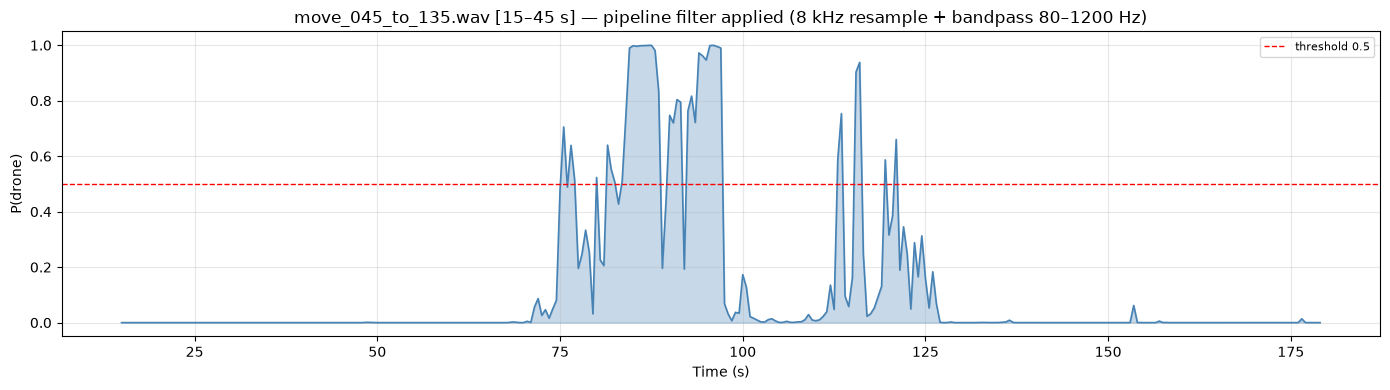

In [25]:
fig, ax = plt.subplots(figsize=(14, 4))
ts, ps = result['timestamps'], result['probs']
ax.fill_between(ts, ps, alpha=0.3, color='steelblue')
ax.plot(ts, ps, color='steelblue', lw=1.2)
ax.axhline(0.5, color='red', lw=1, ls='--', label='threshold 0.5')
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel('P(drone)')
ax.set_xlabel('Time (s)')
ax.set_title('move_045_to_135.wav [15–45 s] — pipeline filter applied (8 kHz resample + bandpass 80–1200 Hz)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Quick sweep: first 10 seconds of every full-channel WAV
import glob, os

files = sorted(f for f in glob.glob("../23-may-2026-wav/*.wav") if "_ch" not in f)
print(f"Found {len(files)} files — testing first 10 s each\n")

results = []
for f in files:
    r = run_file(f, t_start=0, t_end=10)
    results.append(r)
    pct = r['n_detected'] / r['n_total'] * 100
    print(f"{os.path.basename(f):35s}  {r['n_detected']:2d}/{r['n_total']:2d} ({pct:5.1f}%)  mean={r['probs'].mean():.3f}")